<a href="https://colab.research.google.com/github/kuxx12257/LOWESS_w.s.cleveland_research_reproduction/blob/main/ROBUST_LOWESS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##aim: to implement robust lowess and compare it with lowess model

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

In [35]:
np.random.seed(0)

x = np.linspace(0, 10, 100)
y = np.e**(np.sin(x)+np.cos(x)) + np.random.normal(0, 0.3, 100)

# IMPORTANT: sort data
idx = np.argsort(x)
x = x[idx]
y = y[idx]

##GENERATED DATASET

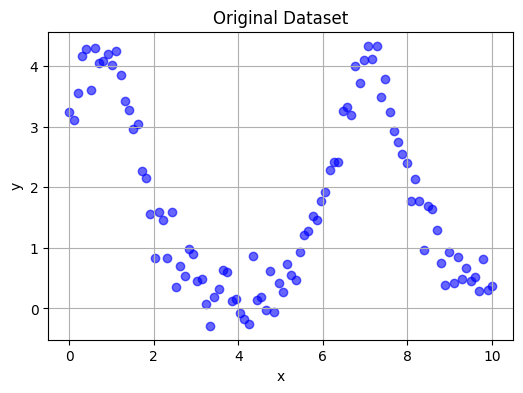

In [36]:
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='blue', alpha=0.6)
plt.title("Original Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [37]:
lowess_result = lowess(y, x, frac=0.3)
x_lowess = lowess_result[:,0]
y_lowess = lowess_result[:,1]

##NORMAL LOWESS MODEL RESULTS

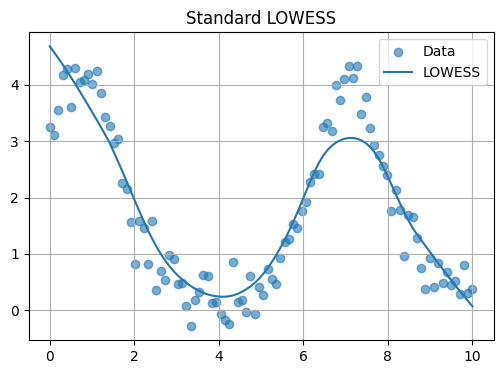

In [38]:
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.6, label="Data")
plt.plot(x_lowess, y_lowess,label="LOWESS")
plt.legend()
plt.title("Standard LOWESS")
plt.grid(True)
plt.show()

##ROBUST LOWESS MODEL FROM SCRATTCH

In [39]:
def robust_lowess(x, y, f=0.3, iters=3):
    n = len(x)
    y_pred = np.zeros(n)
    robust_weights = np.ones(n)

    for iteration in range(iters):
        for i in range(n):
            distances = np.abs(x - x[i])
            h = np.sort(distances)[int(f * n)]


            w = (1 - (distances / h)**3)**3
            w[distances > h] = 0


            w = w * robust_weights

            W = np.diag(w)
            X = np.vstack([np.ones(n), x]).T

            beta = np.linalg.pinv(X.T @ W @ X) @ (X.T @ W @ y)
            y_pred[i] = beta[0] + beta[1] * x[i]


        residuals = np.abs(y - y_pred)
        s = np.median(residuals)

        if s == 0:
            break

        u = residuals / (6 * s)

        robust_weights = np.where(
            u < 1,
            (1 - u**2)**2,
            0
        )

    return y_pred

In [40]:
y_robust = robust_lowess(x, y, f=0.3)

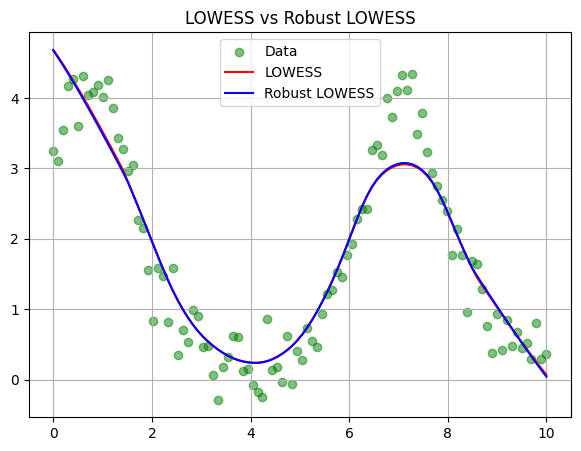

In [54]:
plt.figure(figsize=(7,5))

plt.scatter(x, y, color='grEEN', alpha=0.5, label="Data")
plt.plot(x_lowess, y_lowess, color='red', label="LOWESS")
plt.plot(x, y_robust, color='blue', label="Robust LOWESS")

plt.legend()
plt.title("LOWESS vs Robust LOWESS")
plt.grid(True)
plt.show()
#in case of absence of any extreme outliers the lowess model and robust lowess model
#almost perfectly overlap


##ADDING EXXTREME OUTLIERS

In [46]:
y_out = y.copy()

#extreme outliers
y_out[20:30] += 8
y_out[60:70] -= 8

In [47]:
lowess_out = lowess(y_out, x, frac=0.3)
x_lowess_out = lowess_out[:,0]
y_lowess_out = lowess_out[:,1]

In [48]:
y_robust_out = robust_lowess(x, y_out, f=0.3)

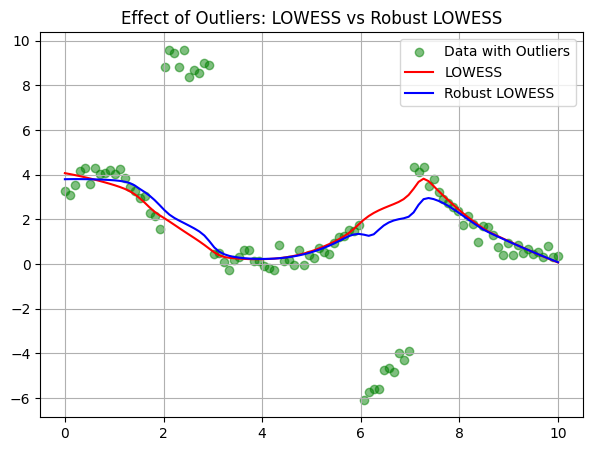

In [53]:
plt.figure(figsize=(7,5))

plt.scatter(x, y_out, color='grEEN', alpha=0.5, label="Data with Outliers")
plt.plot(x_lowess_out, y_lowess_out, color='red', label="LOWESS")
plt.plot(x, y_robust_out, color='blue', label="Robust LOWESS")

plt.legend()
plt.title("Effect of Outliers: LOWESS vs Robust LOWESS")
plt.grid(True)
plt.show()
#as we can see in the plot that lowess is more prone to deviation while robust lowess is less deviated due to the presence of outliers
#hence robust lowess is better when data is randomised and filled with outliers